# Week 5: Topic-model diagnostics, robustness and validity


Week 4 fitted one LDA and one NMF model and showed that they broadly agree. This notebook asks whether those topics, and the institutional differences built on them, can be trusted. It is organised around three tracked topics, each tied to one of the Week 5 dictionary diagnostics:

| Tracked topic | Question |
|---|---|
| **governance** | Is the Council's lead on regulatory governance robust? The dictionary bootstrap found its interval too wide to support a finding. |
| **rights** | Is Parliament's lead on fundamental rights robust? The dictionary interval overlaps the Council's. |
| **digital** | Is the "digital / data" signal a substantive theme, or generic EU technology-policy vocabulary? The dictionary's technological-innovation share was largely carried by such terms. |

Diagnostics:

1. **Preprocessing** — the topic models now use the same tokenisation and stopword lists as the dictionary and Fightin' Words (`represent.py`, `drop_house_style`), so the three routes share one representation. The Week 4 preprocessing is refitted for comparison.
2. **Seed stability** — LDA is refitted with 6 random seeds. LDA optimises a non-convex objective from a random start, so a single run can stop at a local optimum.
3. **K sensitivity** — K = 10 was chosen in Week 4 by maximum coherence, which tends to select too few topics. The model is fitted on ~25,000 paragraphs, for which ~20 topics is the usual rule of thumb, so the models are refitted at K = 20.
4. **Weighting** — the Week 4 topic shares were paragraph-weighted, whereas the dictionary profile is document-weighted (paragraphs averaged within documents, then documents within institutions). Shares are now document-weighted, so the routes are compared on the same aggregation.
5. **Bootstrap** — 95 % intervals from resampling documents within institution, with the same procedure and criterion as the dictionary diagnostics.

Run from the repository root or from `notebooks/`. Set `FAST = True` for a quick test run first. All outputs are written to `reports/week5_topic_diagnostics/`.

In [1]:
from __future__ import annotations

import json
import re
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS,
)

# ---- run configuration -----------------------------------------------------
FAST = False                      # True = fewer refits, for a quick test run
RANDOM_STATE = 0                  
K_REF = 10                        
N_SEEDS = 6   
K_ALT = 20                     
LDA_ITER = 10 if FAST else 25     # Week 4 used 25
MATCH_THRESHOLD = 0.8             # cosine above which a refit topic counts as "the same topic"
N_BOOT = 200 if FAST else 1000  
BOOT_SEED = 42


INSTITUTIONS = ["Commission", "Council", "Parliament"]
INST_COLOURS = {"Commission": "#1f4e79", "Parliament": "#c0504d", "Council": "#7f7f7f"} 


ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT_DIR = ROOT / "reports" / "week5_topic_diagnostics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY: dict = {}
T0 = time.time()

## Load the corpus

In [2]:
# Load the corpus and tokeniser
sys.path.insert(0, str(ROOT / "notebooks"))
import represent  # noqa: E402

paras_raw = pd.read_parquet(ROOT / "data" / "corpus" / "paragraphs.parquet")
if "para_idx" not in paras_raw.columns:
    paras_raw["para_idx"] = paras_raw.groupby("doc_id").cumcount()
print(f"paragraphs: {len(paras_raw):,} | documents: {paras_raw.doc_id.nunique()}")
print(paras_raw.groupby("institution").doc_id.nunique().to_string())

paragraphs: 27,732 | documents: 139
institution
Commission    75
Council       28
Parliament    36


## 0. Preprocessing and the reference model

**New baseline:** tokenisation and the generic, EU-procedural and rhetorical stopword lists from `represent.py` (`drop_house_style`), identical to the dictionary and Fightin' Words. Three topic-model-specific settings are kept from Week 4: figure/table caption paragraphs and citation-URL tokens are removed (both produced spurious topics in Week 4), and `max_df = 0.5` drops terms occurring in more than half of all paragraphs, because topic models are sensitive to very frequent words.

The Week 4 preprocessing is defined here too, for the comparison in the later part.

In [3]:
# Preprocessing: new baseline and the Week 4 version 
CAPTION_PATTERN = re.compile(r"(?i)^\s*(figure|table|chart)\s+\d+\s*[:.]")   # Week 4 caption filter
ELI_TOKENS = {"eli", "http", "https", "europa"}                                # Week 4 citation-URL filter
MIN_TOKENS = 8
VEC_KWARGS = dict(token_pattern=r"\S+", ngram_range=(1, 2), min_df=5, max_df=0.5, max_features=4000)

# Week 4 stopwords, kept only for the preprocessing comparison
WEEK4_STOPWORDS = set(ENGLISH_STOP_WORDS) | ELI_TOKENS | {
    "article", "articles", "paragraph", "paragraphs", "regulation", "regulations",
    "directive", "directives", "shall", "member", "members", "states", "state",
    "union", "european", "commission", "council", "parliament", "annex",
    "recital", "whereas", "pursuant", "hereby", "eu", "eus", "proposal",
}
WEEK4_TOKEN = re.compile(r"[a-zA-Z]{3,}")

def tokens_new(text):
    # Same tokenisation and stopword lists as the dictionary and Fightin' Words ("drop_house_style")
    toks = represent.tokenise(text, drop_generic=True, drop_procedural=True, drop_rhetorical=True)
    return " ".join(t for t in toks if t not in ELI_TOKENS)

def tokens_week4(text):
    return " ".join(w for w in WEEK4_TOKEN.findall(text.lower()) if w not in WEEK4_STOPWORDS)

def prepare(tokeniser):
    df = paras_raw[~paras_raw["text"].str.match(CAPTION_PATTERN)].copy()
    df["text_proc"] = df["text"].map(tokeniser)
    df = df[df["text_proc"].str.split().map(len) >= MIN_TOKENS]
    return df.reset_index(drop=True)

def vectorise(texts, kind):
    vec = (CountVectorizer if kind == "count" else TfidfVectorizer)(**VEC_KWARGS)
    X = vec.fit_transform(texts)
    return X, np.array(vec.get_feature_names_out())

paras = prepare(tokens_new)
X_counts, vocab_c = vectorise(paras["text_proc"], "count")
X_tfidf, vocab_t = vectorise(paras["text_proc"], "tfidf")
print(f"paragraphs modelled: {len(paras):,} | vocabulary: {len(vocab_c):,}")

paragraphs modelled: 25,762 | vocabulary: 4,000


### Helper Functions

In [ ]:
# 
def fit_topics(X, model, k, seed, nmf_init="nndsvda"):
    # Returns (topic-word matrix with rows summing to 1, paragraph-topic matrix with rows summing to 1).
    if model == "LDA":
        m = LatentDirichletAllocation(n_components=k, random_state=seed, max_iter=LDA_ITER,
                                      learning_method="online", batch_size=2048)
    else:
        m = NMF(n_components=k, random_state=seed, init=nmf_init,
                max_iter=300 if nmf_init == "nndsvda" else 600)
    theta = m.fit_transform(X)
    theta = theta / np.clip(theta.sum(axis=1, keepdims=True), 1e-12, None)
    phi = m.components_ / m.components_.sum(axis=1, keepdims=True)
    return phi, theta


def top_words(phi, vocab, n=10):
    return [", ".join(vocab[np.argsort(-row)[:n]]) for row in phi]


def cosine_matrix(phi_a, vocab_a, phi_b, vocab_b):
    # Cosine similarity between every topic of model A and of model B, on their shared vocabulary.
    common = np.intersect1d(vocab_a, vocab_b)
    ia = pd.Index(vocab_a).get_indexer(common)
    ib = pd.Index(vocab_b).get_indexer(common)
    A, B = phi_a[:, ia], phi_b[:, ib]
    A = A / np.linalg.norm(A, axis=1, keepdims=True)
    B = B / np.linalg.norm(B, axis=1, keepdims=True)
    return A @ B.T


def match(phi_ref, vocab_ref, phi_new, vocab_new):
    # One-to-one Hungarian matching of new topics onto reference topics (same K).
    # Returns perm (perm[i] = new topic matched to ref topic i) and the cosine of each pair.
    S = cosine_matrix(phi_ref, vocab_ref, phi_new, vocab_new)
    rows, cols = linear_sum_assignment(-S)
    perm = np.empty(len(rows), dtype=int)
    perm[rows] = cols
    return perm, S[rows, cols][np.argsort(rows)]


def doc_level(theta, meta):
    # Mean topic share within each document
    cols = [f"T{t}" for t in range(theta.shape[1])]
    df = pd.DataFrame(theta, columns=cols)
    df["institution"] = meta["institution"].values
    df["doc_id"] = meta["doc_id"].values
    return df.groupby(["doc_id", "institution"])[cols].mean().reset_index()



def profile(theta, meta, weighting="document"):
    # Institution x topic prevalence, rows normalised to 1 (as in Week 4).
    cols = [f"T{t}" for t in range(theta.shape[1])]
    if weighting == "document":
        tab = doc_level(theta, meta).groupby("institution")[cols].mean()
    else:
        df = pd.DataFrame(theta, columns=cols)
        df["institution"] = meta["institution"].values
        tab = df.groupby("institution")[cols].mean()
    return tab.div(tab.sum(axis=1), axis=0).reindex(INSTITUTIONS)

###  Reference models and tracked topics
The three tracked topics are first chosen automatically as the topics putting most weight on a short list of theme words. For NMF two automatic picks were wrong on their top words and were set by hand: rights (auto T2 = "harmonised rules on AI", title boilerplate → T3, data protection, the closest NMF topic; NMF at K = 10 has no clean rights topic) and digital (auto T3 = personal data → T0, cloud / computing / technologies).

In [6]:
REF = {}
for model, X, vocab in [("LDA", X_counts, vocab_c), ("NMF", X_tfidf, vocab_t)]:
    phi, theta = fit_topics(X, model, K_REF, RANDOM_STATE)
    REF[model] = dict(phi=phi, theta=theta, vocab=vocab, X=X, words=top_words(phi, vocab))
    prof = profile(theta, paras)
    print(f"\n--- {model} (K={K_REF}), document-weighted shares ---")
    for t, w in enumerate(REF[model]["words"]):
        shares = "  ".join(f"{i[:4]} {prof.loc[i, f'T{t}']:.3f}" for i in INSTITUTIONS)
        print(f"  T{t}: {shares} | {w}")

THEMES = {
    "governance": ["authorities", "conformity", "assessment", "enforcement", "surveillance",
                   "competent", "oversight", "compliance", "notified", "harmonised"],
    "rights": ["rights", "fundamental", "discrimination", "privacy", "dignity", "ethical",
               "democracy", "freedom", "charter", "human"],
    "digital": ["digital", "data", "cloud", "computing", "infrastructure", "technologies"],
}

TRACK = {}
for model in REF:
    vocab_index = pd.Index(REF[model]["vocab"])
    TRACK[model] = {}
    for theme, words in THEMES.items():
        idx = [i for i in vocab_index.get_indexer(words) if i >= 0]
        TRACK[model][theme] = int(REF[model]["phi"][:, idx].sum(axis=1).argmax())

# Manual override for NMF, based on the top words above 
TRACK["NMF"]["rights"] = 3    # auto pick T2 = "harmonised rules on AI" (title boilerplate). NMF at K = 10 has
                              # no clean rights topic; T3 (data protection) is the closest, and the dictionary's
                              # fundamental_rights frame also counts "data protection", "gdpr", "privacy".
TRACK["NMF"]["digital"] = 0   # auto pick T3 = personal data. T0 carries cloud, computing, technologies.

for model in REF:
    print(f"\n{model} tracked topics:")
    for theme, t in TRACK[model].items():
        print(f"  {theme:<10} -> T{t}: {REF[model]['words'][t]}")
    if len(set(TRACK[model].values())) < len(THEMES):
        print("  WARNING: two themes picked the same topic")


--- LDA (K=10), document-weighted shares ---
  T0: Comm 0.058  Coun 0.104  Parl 0.061 | data, personal, law, personal data, protection, persons, systems, natural, processing, data protection
  T1: Comm 0.096  Coun 0.050  Parl 0.103 | data, sector, learning, models, systems, use, sectors, education, based, used
  T2: Comm 0.079  Coun 0.051  Parl 0.140 | systems, use, safety, risks, product, system, technologies, products, rules, market
  T3: Comm 0.110  Coun 0.109  Parl 0.046 | stakeholders, was, were, out, respondents, impact, consultation, implementation, assessment, organisations
  T4: Comm 0.151  Coun 0.052  Parl 0.136 | data, services, public, digital, access, market, authorities, national, providers, use
  T5: Comm 0.250  Coun 0.190  Parl 0.217 | digital, europe, development, technologies, artificial, intelligence, artificial intelligence, support, data, innovation
  T6: Comm 0.070  Coun 0.039  Parl 0.046 | smes, eur, start, enterprises, small, ups, start ups, companies, costs, y

## 1. Preprocessing check

Refit with the Week 4 preprocessing and compare with the new baseline: do the topics match (cosine ≥ 0.8), and does the leading institution on each topic stay the same? If yes, harmonising the representation across the three routes does not change the topic-model results; if not, the harmonised version is the one reported.

In [7]:
# Preprocessing check: Week 4 preprocessing vs the new baseline
paras_w4 = prepare(tokens_week4)
prep_rows = []
for model, kind in [("LDA", "count"), ("NMF", "tfidf")]:
    X_w4, vocab_w4 = vectorise(paras_w4["text_proc"], kind)
    phi_w4, theta_w4 = fit_topics(X_w4, model, K_REF, RANDOM_STATE)
    perm, cos = match(REF[model]["phi"], REF[model]["vocab"], phi_w4, vocab_w4)
    prof_new = profile(REF[model]["theta"], paras)
    prof_w4 = profile(theta_w4[:, perm], paras_w4)
    for t in range(K_REF):
        prep_rows.append(dict(model=model, topic=t, cosine=round(float(cos[t]), 3),
                              leader_new=prof_new[f"T{t}"].idxmax(), leader_week4=prof_w4[f"T{t}"].idxmax(),
                              top_words=REF[model]["words"][t][:60]))
prep = pd.DataFrame(prep_rows)
prep["same_leader"] = prep.leader_new == prep.leader_week4
prep.to_csv(OUT_DIR / "preprocessing_check.csv", index=False)
print(prep.to_string(index=False))
for model in REF:
    p = prep[prep.model == model]
    SUMMARY[f"prep_{model}_topics_matched_of_{K_REF}"] = int((p.cosine >= MATCH_THRESHOLD).sum())
    SUMMARY[f"prep_{model}_topics_same_leader_of_{K_REF}"] = int(p.same_leader.sum())
    for theme, t in TRACK[model].items():
        SUMMARY[f"prep_{model}_{theme}_cosine"] = float(p.loc[p.topic == t, "cosine"].iloc[0])

model  topic  cosine leader_new leader_week4                                                    top_words  same_leader
  LDA      0   0.653    Council   Parliament data, personal, law, personal data, protection, persons, sys        False
  LDA      1   0.683 Parliament   Parliament data, sector, learning, models, systems, use, sectors, educa         True
  LDA      2   0.341 Parliament      Council systems, use, safety, risks, product, system, technologies,         False
  LDA      3   0.284 Commission      Council stakeholders, was, were, out, respondents, impact, consultat        False
  LDA      4   0.804 Commission   Commission data, services, public, digital, access, market, authorities         True
  LDA      5   0.831 Commission   Commission digital, europe, development, technologies, artificial, inte         True
  LDA      6   0.348 Commission   Commission smes, eur, start, enterprises, small, ups, start ups, compan         True
  LDA      7   0.851    Council      Council sys

## 2. Seed stability

LDA is refitted with 6 further seeds and each refit is matched onto the reference topics. A topic matched at cosine ≥ 0.8 in (almost) every run reflects structure in the data; a topic that often falls below reflects one particular run and should not carry an interpretation. NMF is not included: with `nndsvda` initialisation it is deterministic, so the seed has no effect on it.

In [ ]:
# Seed stability (LDA only; NMF with nndsvda initialisation is deterministic, so the seed has no effect)
seed_rows = []
for s in range(1, N_SEEDS + 1):
    phi, theta = fit_topics(REF["LDA"]["X"], "LDA", K_REF, s)
    perm, cos = match(REF["LDA"]["phi"], REF["LDA"]["vocab"], phi, REF["LDA"]["vocab"])
    prof = profile(theta[:, perm], paras)
    for t in range(K_REF):
        seed_rows.append(dict(seed=s, topic=t, cosine=cos[t],
                              **{inst: prof.loc[inst, f"T{t}"] for inst in INSTITUTIONS}))
    print(f"  seed {s} done ({time.time() - T0:.0f}s)")
seeds = pd.DataFrame(seed_rows)
seeds.to_csv(OUT_DIR / "seed_stability_runs.csv", index=False)

g = seeds.groupby("topic")["cosine"]
seed_tab = pd.DataFrame({"mean_cos": g.mean(), "min_cos": g.min(),
                         "share_runs_matched": g.apply(lambda c: (c >= MATCH_THRESHOLD).mean())}).round(3)
seed_tab["top_words"] = [w[:60] for w in REF["LDA"]["words"]]
seed_tab.to_csv(OUT_DIR / "seed_stability.csv")
print(seed_tab.to_string())

print("\nTracked topics: range of document-weighted shares across seeds")
for theme, t in TRACK["LDA"].items():
    sub = seeds[seeds.topic == t]
    ranges = " | ".join(f"{i[:4]} {sub[i].min():.3f}-{sub[i].max():.3f}" for i in INSTITUTIONS)
    print(f"  {theme:<10} T{t}: {ranges}")
    SUMMARY[f"seed_LDA_{theme}_share_runs_matched"] = float(seed_tab.loc[t, "share_runs_matched"])
SUMMARY[f"seed_LDA_stable_topics_of_{K_REF}"] = int((seed_tab.share_runs_matched >= 0.8).sum())

  seed 1 done (821s)
  seed 2 done (935s)
  seed 3 done (1052s)
  seed 4 done (1163s)
  seed 5 done (1276s)
  seed 6 done (1395s)
       mean_cos  min_cos  share_runs_matched                                                     top_words
topic                                                                                                     
0         0.722    0.434               0.167  data, personal, law, personal data, protection, persons, sys
1         0.827    0.725               0.500  data, sector, learning, models, systems, use, sectors, educa
2         0.471    0.294               0.000  systems, use, safety, risks, product, system, technologies, 
3         0.609    0.261               0.167  stakeholders, was, were, out, respondents, impact, consultat
4         0.554    0.484               0.000  data, services, public, digital, access, market, authorities
5         0.846    0.768               0.667  digital, europe, development, technologies, artificial, inte
6         0.51

## 3. K sensitivity （K=20)

**Why this value of K.** Week 4 chose K = 10 because it had the highest coherence in {5, 8, 10, 12}. Coherence-maximisation is known to favour too few topics, and there is no objectively correct K, so K = 10 is kept as the reference only for continuity with Week 4. This section tests one alternative, K = 20, to check whether the tracked topics and their leading institution survive a finer-grained decomposition.

In [9]:
# K sensitivity: K = 20. A K = 10 topic may split into several K = 20 topics, so each K = 20
# topic is assigned to the K = 10 topic it most resembles and the pieces are recombined.
k_rows = []
for model in REF:
    vocab = REF[model]["vocab"]
    phi, theta = fit_topics(REF[model]["X"], model, K_ALT, RANDOM_STATE)
    S = cosine_matrix(REF[model]["phi"], vocab, phi, vocab)
    parent = S.argmax(axis=0)
    prevalence = theta.mean(axis=0)
    prof_ref, prof_alt = profile(REF[model]["theta"], paras), profile(theta, paras)
    alt_words = top_words(phi, vocab, n=6)
    for t in range(K_REF):
        children = np.where(parent == t)[0]
        if len(children):
            family = (phi[children] * prevalence[children, None]).sum(axis=0)
            ref = REF[model]["phi"][t]
            fam_cos = float(family @ ref / (np.linalg.norm(family) * np.linalg.norm(ref)))
            fam_share = prof_alt[[f"T{j}" for j in children]].sum(axis=1)
            desc = " | ".join(alt_words[j] for j in children)
        else:  # absorbed into another topic
            best = int(S[t].argmax())
            fam_cos, fam_share = float(S[t, best]), prof_alt[f"T{best}"]
            desc = f"(absorbed into: {alt_words[best]})"
        k_rows.append(dict(model=model, topic=t, family_cos=round(fam_cos, 3), n_children=len(children),
                           leader_K10=prof_ref[f"T{t}"].idxmax(), leader_K20=fam_share.idxmax(), children=desc))
    print(f"  {model} K={K_ALT} done ({time.time() - T0:.0f}s)")
ktab = pd.DataFrame(k_rows)
ktab["same_leader"] = ktab.leader_K10 == ktab.leader_K20
ktab.to_csv(OUT_DIR / "k20_check.csv", index=False)
print(ktab.drop(columns="children").to_string(index=False))

print("\nTracked topics at K = 20:")
for model in REF:
    for theme, t in TRACK[model].items():
        r = ktab[(ktab.model == model) & (ktab.topic == t)].iloc[0]
        print(f"  {model} {theme:<10} T{t}: cos {r.family_cos:.2f}, {r.leader_K10} -> {r.leader_K20}")
        print(f"      pieces: {r.children}")
        SUMMARY[f"K20_{model}_{theme}_family_cos"] = float(r.family_cos)
        SUMMARY[f"K20_{model}_{theme}_same_leader"] = bool(r.same_leader)
for model in REF:
    k = ktab[ktab.model == model]
    SUMMARY[f"K20_{model}_topics_recovered_of_{K_REF}"] = int((k.family_cos >= MATCH_THRESHOLD).sum())

  LDA K=20 done (1509s)
  NMF K=20 done (1513s)
model  topic  family_cos  n_children leader_K10 leader_K20  same_leader
  LDA      0       0.900           2    Council    Council         True
  LDA      1       0.894           3 Parliament Parliament         True
  LDA      2       0.564           0 Parliament Parliament         True
  LDA      3       0.795           1 Commission    Council        False
  LDA      4       0.681           1 Commission Parliament        False
  LDA      5       0.925           4 Commission    Council        False
  LDA      6       0.662           3 Commission Commission         True
  LDA      7       0.954           3    Council    Council         True
  LDA      8       0.584           2 Parliament    Council        False
  LDA      9       0.869           1    Council Commission        False
  NMF      0       0.830           5 Commission Commission         True
  NMF      1       0.961           3    Council    Council         True
  NMF      2    

## 4. Weighting

Paragraph-weighted (Week 4) versus document-weighted shares for the tracked topics. Under paragraph weighting a single long document with hundreds of paragraphs can dominate an institution's profile; document weighting counts each document once, as the dictionary profile does.

In [10]:
# Weighting: Week 4 (paragraph-weighted) vs document-weighted (= dictionary aggregation)
w_rows = []
for model in REF:
    p_par = profile(REF[model]["theta"], paras, "paragraph")
    p_doc = profile(REF[model]["theta"], paras, "document")
    for theme, t in TRACK[model].items():
        for inst in INSTITUTIONS:
            w_rows.append(dict(model=model, theme=theme, topic=t, institution=inst,
                               paragraph_weighted=round(p_par.loc[inst, f"T{t}"], 3),
                               document_weighted=round(p_doc.loc[inst, f"T{t}"], 3)))
weights = pd.DataFrame(w_rows)
weights.to_csv(OUT_DIR / "weighting_comparison.csv", index=False)
print(weights.to_string(index=False))

model      theme  topic institution  paragraph_weighted  document_weighted
  LDA governance      7  Commission               0.058              0.041
  LDA governance      7     Council               0.416              0.199
  LDA governance      7  Parliament               0.154              0.058
  LDA     rights      8  Commission               0.079              0.078
  LDA     rights      8     Council               0.038              0.078
  LDA     rights      8  Parliament               0.120              0.126
  LDA    digital      5  Commission               0.212              0.250
  LDA    digital      5     Council               0.096              0.190
  LDA    digital      5  Parliament               0.162              0.217
  NMF governance      9  Commission               0.042              0.037
  NMF governance      9     Council               0.100              0.049
  NMF governance      9  Parliament               0.048              0.028
  NMF     rights      3  

## 5. Bootstrap intervals

Documents are resampled with replacement within each institution (1,000 draws, seed 42) and the document-weighted shares recomputed, giving 95 % percentile intervals. The corpus is a population rather than a sample, so the interval answers a narrower question: how much does a difference depend on which particular documents an institution happened to produce? The topics are held fixed during resampling; model instability is covered in the seed and K checks above. A lead is reported as robust only if the leader's interval does not overlap the runner-up's.

In [11]:
# Bootstrap: same procedure as the dictionary diagnostics (resample documents with replacement within institution,
# 1,000 draws, seed 42, 95% percentile interval). A lead counts as robust only if the
# leader's interval does not overlap the runner-up's (same criterion as the dictionary).
def bootstrap_topics(theta, meta):
    per_doc = doc_level(theta, meta)
    cols = [c for c in per_doc.columns if c.startswith("T")]

    def shares(docs):
        tab = docs.groupby("institution")[cols].mean()
        return tab.div(tab.sum(axis=1), axis=0).reindex(INSTITUTIONS)

    point = shares(per_doc)
    rng = np.random.default_rng(BOOT_SEED)
    groups = [g.reset_index(drop=True) for _, g in per_doc.groupby("institution")]
    draws = np.stack([shares(pd.concat([g.iloc[rng.integers(0, len(g), len(g))] for g in groups])).values
                      for _ in range(N_BOOT)])
    lo, hi = np.percentile(draws, 2.5, axis=0), np.percentile(draws, 97.5, axis=0)
    return pd.DataFrame([dict(institution=inst, topic=j, point=point.iloc[i, j], ci_low=lo[i, j], ci_high=hi[i, j])
                         for i, inst in enumerate(INSTITUTIONS) for j in range(len(cols))])


boot_parts = []
for model in REF:
    b = bootstrap_topics(REF[model]["theta"], paras)
    b.insert(0, "model", model)
    boot_parts.append(b)
boot = pd.concat(boot_parts).round(3)
boot.to_csv(OUT_DIR / "bootstrap_topic_shares.csv", index=False)

for model in REF:
    print(f"\n--- {model} ---")
    for theme, t in TRACK[model].items():
        sub = boot[(boot.model == model) & (boot.topic == t)].sort_values("point", ascending=False)
        lead, second = sub.iloc[0], sub.iloc[1]
        robust = bool(lead.ci_low > second.ci_high)
        cis = " | ".join(f"{r.institution[:4]} {r.point:.3f} [{r.ci_low:.3f}, {r.ci_high:.3f}]" for r in sub.itertuples())
        print(f"  {theme:<10} T{t}: leader {lead.institution:<10} robust={robust!s:<5} {cis}")
        SUMMARY[f"boot_{model}_{theme}_leader"] = lead.institution
        SUMMARY[f"boot_{model}_{theme}_lead_robust"] = robust


--- LDA ---
  governance T7: leader Council    robust=True  Coun 0.199 [0.116, 0.291] | Parl 0.058 [0.028, 0.098] | Comm 0.041 [0.026, 0.059]
  rights     T8: leader Parliament robust=False Parl 0.126 [0.090, 0.166] | Comm 0.078 [0.060, 0.097] | Coun 0.078 [0.042, 0.121]
  digital    T5: leader Commission robust=False Comm 0.250 [0.207, 0.293] | Parl 0.217 [0.166, 0.273] | Coun 0.190 [0.120, 0.268]

--- NMF ---
  governance T9: leader Council    robust=False Coun 0.049 [0.033, 0.067] | Comm 0.037 [0.031, 0.045] | Parl 0.028 [0.020, 0.037]
  rights     T3: leader Parliament robust=False Parl 0.099 [0.075, 0.130] | Comm 0.095 [0.078, 0.115] | Coun 0.072 [0.058, 0.088]
  digital    T0: leader Commission robust=False Comm 0.261 [0.226, 0.296] | Parl 0.195 [0.162, 0.230] | Coun 0.101 [0.070, 0.139]


## 6. Figure

Tracked topics for LDA (left) and NMF (right): document-weighted shares with 95 % bootstrap intervals (filled) and the Week 4 paragraph-weighted value (hollow).

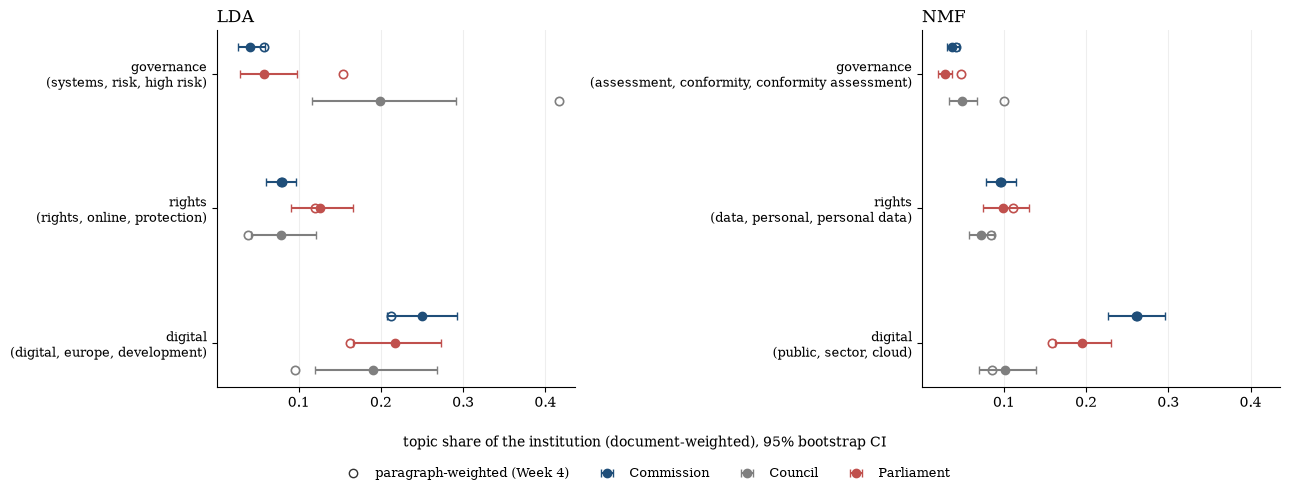

In [12]:
# Figure: tracked topics, document-weighted shares with 95% bootstrap intervals (same style as the dictionary bootstrap figure).
# Hollow markers = Week 4 paragraph-weighted value.
plt.rcParams.update({"font.family": "serif"})
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharex=True)
offsets = {"Commission": -0.2, "Parliament": 0.0, "Council": 0.2}
for ax, model in zip(axes, REF):
    themes = list(TRACK[model])
    for i, theme in enumerate(themes):
        t = TRACK[model][theme]
        for inst in INSTITUTIONS:
            r = boot[(boot.model == model) & (boot.topic == t) & (boot.institution == inst)].iloc[0]
            y = i + offsets[inst]
            ax.errorbar(r.point, y, xerr=[[r.point - r.ci_low], [r.ci_high - r.point]], fmt="o",
                        color=INST_COLOURS[inst], ms=6, capsize=3, lw=1.5,
                        label=inst if (i == 0 and model == "LDA") else None)
            pw = weights[(weights.model == model) & (weights.topic == t) & (weights.institution == inst)].paragraph_weighted.iloc[0]
            ax.plot(pw, y, "o", mfc="none", mec=INST_COLOURS[inst], ms=6, mew=1.2)
    ax.set_yticks(range(len(themes)),
                  [f"{th}\n({', '.join(REF[model]['words'][TRACK[model][th]].split(', ')[:3])})" for th in themes],
                  fontsize=9)
    ax.invert_yaxis()
    ax.grid(axis="x", color="#eeeeee", zorder=0)
    ax.set_title(f"{model}", fontsize=12, loc="left")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].plot([], [], "o", mfc="none", mec="#333333", ms=6, label="paragraph-weighted (Week 4)")
fig.supxlabel("topic share of the institution (document-weighted), 95% bootstrap CI", fontsize=10)
fig.legend(frameon=False, fontsize=9, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.08))
fig.tight_layout()
fig.savefig(OUT_DIR / "figure_topic_bootstrap.png", dpi=200, bbox_inches="tight")
plt.show()